In [1]:
import sklearn
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import numpy

In [2]:
corpus = [
"Machine learning is super fun",
"Python is super, super cool",
"Statistics is cool, too",
"Data science is fun",
"Python is great for machine learning",
"I like football",
"Football is great to watch"
]

In [3]:
corpus

['Machine learning is super fun',
 'Python is super, super cool',
 'Statistics is cool, too',
 'Data science is fun',
 'Python is great for machine learning',
 'I like football',
 'Football is great to watch']

In [4]:
vectorizer = CountVectorizer()

In [5]:
vectorizer

CountVectorizer()

### Bag of Words Model

CountVectorizer is a feature extraction method in NLP that converts a collection of text documents into a matrix of token counts. 

This is often the first step in text preprocessing for machine learning models like Naive Bayes, Logistic Regression, or SVM for text classification.

    Each row = document
    
    Each column = unique word
    
    Each value = count of that word in that document

    
    It creates a vocabulary of all unique words in your corpus.
    
    Then it counts how many times each word occurs in each document.
    
    The output is a document-term matrix (rows = documents, columns = words, values = counts).


| Parameter       | Description                                   | Example                                       |
| --------------- | --------------------------------------------- | --------------------------------------------- |
| `stop_words`    | Words to ignore                               | `stop_words='english'`                        |
| `max_features`  | Keep only top N frequent words                | `max_features=10`                             |
| `ngram_range`   | Include n-grams (sequence of words)           | `ngram_range=(1,2)` → unigrams + bigrams      |
| `lowercase`     | Convert all text to lowercase                 | `lowercase=True`                              |
| `token_pattern` | Regex for token extraction                    | `token_pattern=r'\b\w+\b'`                    |
| `min_df`        | Ignore words in fewer than `min_df` documents | `min_df=2`                                    |
| `max_df`        | Ignore words in more than `max_df` documents  | `max_df=0.8` → ignore words in 80%+ documents |


Advantages:

    Simple and fast.
    
    Works well for bag-of-words models.
    
    Supports n-grams and stopword removal.

Limitations:

    Ignores word order (bag-of-words).
    
    High-dimensional if vocabulary is large → sparse matrix.
    
    Does not capture meaning or context (like Word2Vec or Transformers do).

In [6]:

dtm = vectorizer.fit_transform(corpus)
dtm

<7x17 sparse matrix of type '<class 'numpy.int64'>'
	with 30 stored elements in Compressed Sparse Row format>

In [8]:

vectorizer.get_feature_names_out()

array(['cool', 'data', 'football', 'for', 'fun', 'great', 'is',
       'learning', 'like', 'machine', 'python', 'science', 'statistics',
       'super', 'to', 'too', 'watch'], dtype=object)

In [7]:

dtm.shape

(7, 17)

In [9]:

pd.DataFrame(dtm.toarray(),index=corpus,columns=vectorizer.get_feature_names_out())

,cool,data,football,for,fun,great,is,learning,like,machine,python,science,statistics,super,to,too,watch
Machine learning is super fun,0,0,0,0,1,0,1,1,0,1,0,0,0,1,0,0,0
"Python is super, super cool",1,0,0,0,0,0,1,0,0,0,1,0,0,2,0,0,0
"Statistics is cool, too",1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0
Data science is fun,0,1,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0
Python is great for machine learning,0,0,0,1,0,1,1,1,0,1,1,0,0,0,0,0,0
I like football,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0
Football is great to watch,0,0,1,0,0,1,1,0,0,0,0,0,0,0,1,0,1


In [12]:

vectorizer = CountVectorizer(stop_words='english', max_df=0.7, min_df=0.1, max_features=15)

dtm = vectorizer.fit_transform(corpus)

pd.DataFrame(dtm.toarray(),index=corpus,columns=vectorizer.get_feature_names_out())


,cool,data,football,fun,great,learning,like,machine,python,science,statistics,super,watch
Machine learning is super fun,0,0,0,1,0,1,0,1,0,0,0,1,0
"Python is super, super cool",1,0,0,0,0,0,0,0,1,0,0,2,0
"Statistics is cool, too",1,0,0,0,0,0,0,0,0,0,1,0,0
Data science is fun,0,1,0,1,0,0,0,0,0,1,0,0,0
Python is great for machine learning,0,0,0,0,1,1,0,1,1,0,0,0,0
I like football,0,0,1,0,0,0,1,0,0,0,0,0,0
Football is great to watch,0,0,1,0,1,0,0,0,0,0,0,0,1


In [13]:

vectorizer = CountVectorizer(stop_words='english', ngram_range=(1,2), max_df=0.8, min_df=0.1, max_features=10)

dtm = vectorizer.fit_transform(corpus)

pd.DataFrame(dtm.toarray(),index=corpus,columns=vectorizer.get_feature_names_out())


,cool,football,fun,great,great machine,learning,machine,machine learning,python,super
Machine learning is super fun,0,0,1,0,0,1,1,1,0,1
"Python is super, super cool",1,0,0,0,0,0,0,0,1,2
"Statistics is cool, too",1,0,0,0,0,0,0,0,0,0
Data science is fun,0,0,1,0,0,0,0,0,0,0
Python is great for machine learning,0,0,0,1,1,1,1,1,1,0
I like football,0,1,0,0,0,0,0,0,0,0
Football is great to watch,0,1,0,1,0,0,0,0,0,0


In [14]:

vectorizer = CountVectorizer(analyzer='char_wb')

dtm = vectorizer.fit_transform(corpus)

pd.DataFrame(dtm.toarray(),index=corpus,columns=vectorizer.get_feature_names_out())

,,",",a,b,c,d,e,f,g,h,...,m,n,o,p,r,s,t,u,w,y
Machine learning is super fun,10,0,2,0,1,0,3,1,1,1,...,1,4,0,1,2,2,0,2,0,0
"Python is super, super cool",10,1,0,0,1,0,2,0,0,1,...,0,1,3,3,2,3,1,2,0,1
"Statistics is cool, too",8,1,1,0,2,0,0,0,0,0,...,0,0,4,0,0,4,4,0,0,0
Data science is fun,8,0,2,0,2,1,2,1,0,0,...,0,2,0,0,0,2,1,1,0,0
Python is great for machine learning,12,0,3,0,1,0,3,1,2,2,...,1,4,2,1,3,1,2,0,0,1
I like football,6,0,1,1,0,0,1,1,0,0,...,0,0,2,0,0,0,1,0,0,0
Football is great to watch,10,0,3,1,1,0,1,1,1,1,...,0,0,3,0,1,1,4,0,1,0


TF-IDF stands for Term Frequency – Inverse Document Frequency.

It’s a technique to weight words in a text corpus based on their importance:

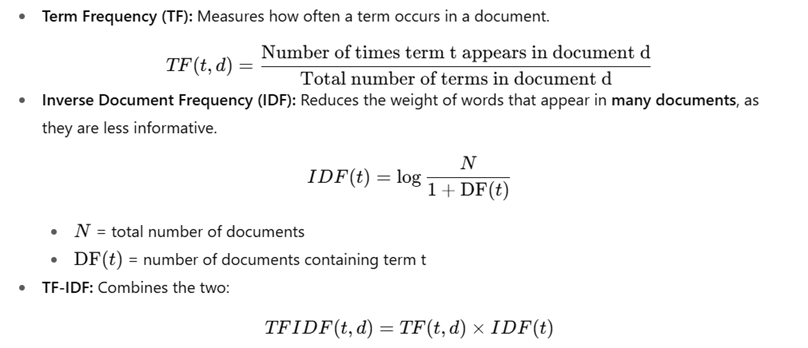

In [15]:
from IPython.display import Image, display

# Display an image
display(Image(filename='tfidf.png'))

In [18]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer

pd.set_option('display.width', 600)

docs = [
    "Machine learning is super fun",
    "Python is super, super cool",
    "Statistics is cool, too",
    "Data science is fun",
    "Python is great for machine learning",
    "I like football",
    "Football is great to watch"
]

cv = CountVectorizer()
X_counts = cv.fit_transform(docs)  # sparse count matrix


In [19]:

dtm_df = pd.DataFrame(X_counts.toarray(), columns=cv.get_feature_names_out())

print(" Document-Term Matrix (TF counts):\n")
print(dtm_df)


 Document-Term Matrix (TF counts):

   cool  data  football  for  fun  great  is  learning  like  machine  python  science  statistics  super  to  too  watch
0     0     0         0    0    1      0   1         1     0        1       0        0           0      1   0    0      0
1     1     0         0    0    0      0   1         0     0        0       1        0           0      2   0    0      0
2     1     0         0    0    0      0   1         0     0        0       0        0           1      0   0    1      0
3     0     1         0    0    1      0   1         0     0        0       0        1           0      0   0    0      0
4     0     0         0    1    0      1   1         1     0        1       1        0           0      0   0    0      0
5     0     0         1    0    0      0   0         0     1        0       0        0           0      0   0    0      0
6     0     0         1    0    0      1   1         0     0        0       0        0           0      0   1 

In [20]:

tfidf_transformer = TfidfTransformer()
X_tfidf = tfidf_transformer.fit_transform(X_counts)  # sparse TF-IDF matrix

tfidf_df = pd.DataFrame(X_tfidf.toarray(), columns=cv.get_feature_names_out())
print("\n TF-IDF Matrix (Vector Space Model):\n")
print(tfidf_df)



 TF-IDF Matrix (Vector Space Model):

       cool      data  football       for       fun     great        is  learning      like  machine    python   science  statistics     super        to       too     watch
0  0.000000  0.000000  0.000000  0.000000  0.480710  0.000000  0.275087   0.48071  0.000000  0.48071  0.000000  0.000000    0.000000  0.480710  0.000000  0.000000  0.000000
1  0.397544  0.000000  0.000000  0.000000  0.000000  0.000000  0.227495   0.00000  0.000000  0.00000  0.397544  0.000000    0.000000  0.795087  0.000000  0.000000  0.000000
2  0.486214  0.000000  0.000000  0.000000  0.000000  0.000000  0.278236   0.00000  0.000000  0.00000  0.000000  0.000000    0.585739  0.000000  0.000000  0.585739  0.000000
3  0.000000  0.585739  0.000000  0.000000  0.486214  0.000000  0.278236   0.00000  0.000000  0.00000  0.000000  0.585739    0.000000  0.000000  0.000000  0.000000  0.000000
4  0.000000  0.000000  0.000000  0.501141  0.000000  0.415990  0.238051   0.41599  0.000000  0.4

In [21]:

first_doc_vector = tfidf_df.iloc[0]
print(first_doc_vector.sort_values(ascending=False))


fun           0.480710
super         0.480710
learning      0.480710
machine       0.480710
is            0.275087
cool          0.000000
science       0.000000
too           0.000000
to            0.000000
statistics    0.000000
like          0.000000
python        0.000000
data          0.000000
great         0.000000
for           0.000000
football      0.000000
watch         0.000000
Name: 0, dtype: float64


TfidfVectorizer:

    Converts a collection of text documents into a matrix of TF-IDF features.
    
    Each row = document, each column = term (word) from the vocabulary.
    
    Values = TF-IDF weight of the term in that document.

Advantages:

    Single step (no need for separate CountVectorizer + TfidfTransformer)
    
    Supports preprocessing (stop words, n-grams, lowercase)
    
    Outputs sparse matrix by default

In [23]:
pd.set_option('display.width', 900)

In [24]:
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer

docs = [
    "Machine learning is super fun",
    "Python is super, super cool",
    "Statistics is cool, too",
    "Data science is fun",
    "Python is great for machine learning",
    "I like football",
    "Football is great to watch"
]

vectorizer = TfidfVectorizer()

X_tfidf = vectorizer.fit_transform(docs)

feature_names = vectorizer.get_feature_names_out()
tfidf_df = pd.DataFrame(X_tfidf.toarray(), columns=feature_names)
print(" TF-IDF Matrix (Vector Space Model):\n")
print(tfidf_df)

idf_df = pd.DataFrame(vectorizer.idf_, index=feature_names, columns=["idf_weights"])
print("\n IDF Weights per word:\n")
print(idf_df)


 TF-IDF Matrix (Vector Space Model):

       cool      data  football       for       fun     great        is  learning      like  machine    python   science  statistics     super        to       too     watch
0  0.000000  0.000000  0.000000  0.000000  0.480710  0.000000  0.275087   0.48071  0.000000  0.48071  0.000000  0.000000    0.000000  0.480710  0.000000  0.000000  0.000000
1  0.397544  0.000000  0.000000  0.000000  0.000000  0.000000  0.227495   0.00000  0.000000  0.00000  0.397544  0.000000    0.000000  0.795087  0.000000  0.000000  0.000000
2  0.486214  0.000000  0.000000  0.000000  0.000000  0.000000  0.278236   0.00000  0.000000  0.00000  0.000000  0.000000    0.585739  0.000000  0.000000  0.585739  0.000000
3  0.000000  0.585739  0.000000  0.000000  0.486214  0.000000  0.278236   0.00000  0.000000  0.00000  0.000000  0.585739    0.000000  0.000000  0.000000  0.000000  0.000000
4  0.000000  0.000000  0.000000  0.501141  0.000000  0.415990  0.238051   0.41599  0.000000  0.41

| Aspect               | `CountVectorizer + TfidfTransformer`          | `TfidfVectorizer`                                       |
| -------------------- | --------------------------------------------- | ------------------------------------------------------- |
| Input                | Explicit CountVectorizer output               | Raw text                                                |
| Tokenization         | Controlled by CountVectorizer                 | Controlled internally by TfidfVectorizer                |
| Preprocessing        | Lowercase, stop words from CountVectorizer    | Defaults may differ (e.g., `lowercase=True`)            |
| Smoothing IDF        | Default `smooth_idf=True` in TfidfTransformer | Also `smooth_idf=True` by default, but you can override |
| Sublinear TF scaling | Optional (`sublinear_tf=True`)                | Optional (`sublinear_tf=True`)                          |
| Normalization        | Optional (`norm='l2'`)                        | Default `norm='l2'`                                     |
